Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


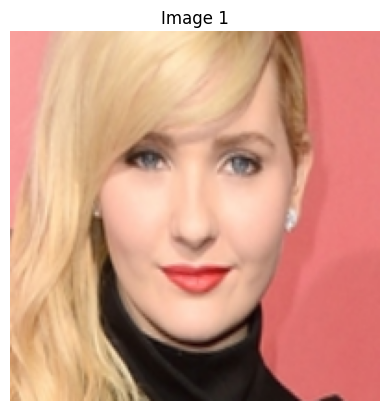

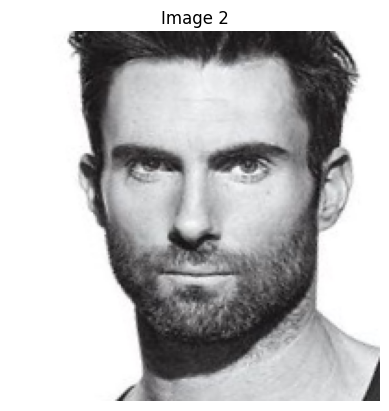

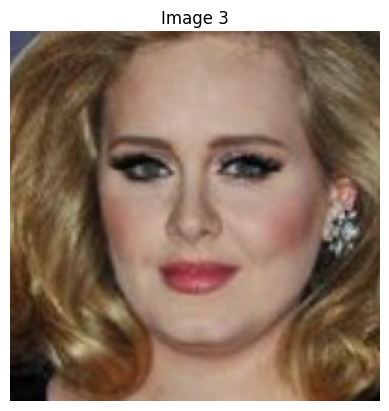

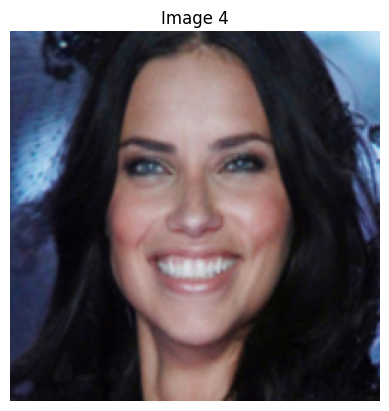

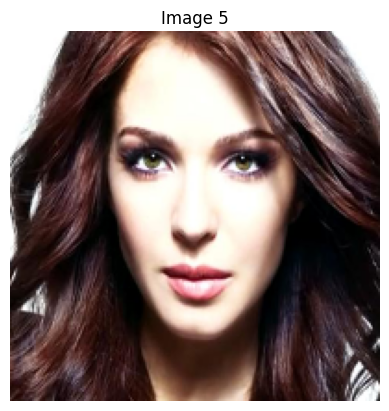

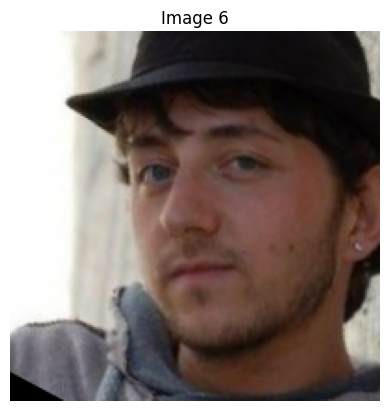

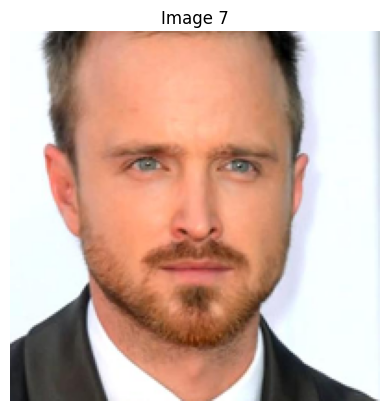

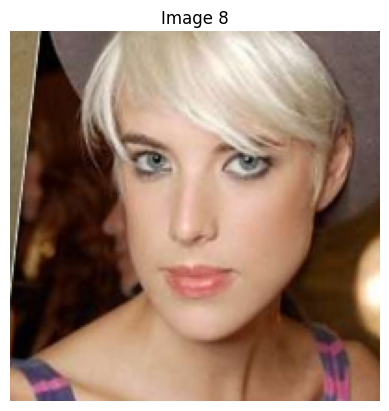

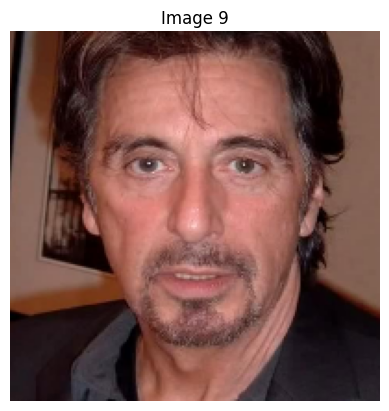

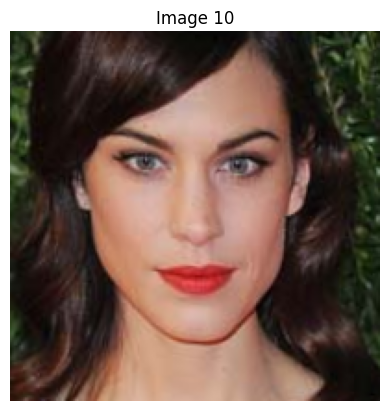

In [3]:
import matplotlib.pyplot as plt
import os
from PIL import Image
from google.colab import drive
drive.mount('/content/drive')
# Directory containing the images
adult_version = '/content/drive/MyDrive/data/adult_version'
kid_version = '/content/drive/MyDrive/data/kid_version'
image_dir = '/content/drive/MyDrive/data/adult_version'

# List images
images = os.listdir(image_dir)

# Display a few images
for i, img_name in enumerate(images[:10]):  # Change the number to view more
    img_path = os.path.join(image_dir, img_name)
    img = Image.open(img_path)
    plt.figure()
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Image {i+1}")
    plt.show()


In [4]:
import os
import cv2
import numpy as np
from glob import glob

# Libraries for deep learning
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


In [5]:
def load_images(image_dir, target_size=(200, 200)):
    images = []
    for file_path in glob(os.path.join(image_dir, "*.png")):
        # Read image
        img = cv2.imread(file_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
        img = cv2.resize(img, target_size)  # Resize to target size
        img = img / 255.0  # Normalize pixel values to [0, 1]
        images.append(img)
    return np.array(images)

# Load adult and child images
adult_images = load_images(adult_version)
kid_images = load_images(kid_version)

print(f"Adult images shape: {adult_images.shape}")
print(f"Kid images shape: {kid_images.shape}")


Adult images shape: (20, 200, 200, 3)
Kid images shape: (20, 200, 200, 3)


In [7]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert to tensor
    transforms.Resize((200, 200)),  # Resize to match input size
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1, 1]
])

# Custom Dataset


class ActorImageDataset(Dataset):
    def __init__(self, adult_images, kid_images, transform=None):
        assert len(adult_images) == len(kid_images), "Mismatch in number of adult and child images"
        self.adult_images = adult_images
        self.kid_images = kid_images
        self.transform = transform

    def __len__(self):
        return len(self.adult_images)

    def __getitem__(self, idx):
        adult_image = self.adult_images[idx]
        kid_image = self.kid_images[idx]

        # Ensure the image data is uint8 for compatibility
        if adult_image.dtype != np.uint8:
            adult_image = (adult_image * 255).astype(np.uint8)
        if kid_image.dtype != np.uint8:
            kid_image = (kid_image * 255).astype(np.uint8)

        # Convert to PIL images
        adult_image = Image.fromarray(adult_image)
        kid_image = Image.fromarray(kid_image)

        # Apply transformations
        if self.transform:
            adult_image = self.transform(adult_image)
            kid_image = self.transform(kid_image)

        return adult_image, kid_image


# Convert numpy arrays to dataset
dataset = ActorImageDataset(adult_images, kid_images, transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# Print the shapes
for adult_img, kid_img in dataloader:
    print("Batch of adult images:", adult_img.shape)  # (batch_size, 3, 200, 200)
    print("Batch of child images:", kid_img.shape)  # (batch_size, 3, 200, 200)
    break


Batch of adult images: torch.Size([4, 3, 200, 200])
Batch of child images: torch.Size([4, 3, 200, 200])


In [8]:
import torch.nn as nn

# Generator Model (U-Net-like)
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh(),  # Output in range [-1, 1]
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# Discriminator Model
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(256 * 25 * 25, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x)


In [16]:
import torch.optim as optim

# Initialize models, loss, and optimizers
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator().to(device)
discriminator = Discriminator().to(device)

criterion_GAN = nn.BCELoss()  # Binary Cross-Entropy for GAN loss
criterion_L1 = nn.L1Loss()  # L1 loss for pixel similarity

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# Training Loop
num_epochs = 200
for epoch in range(num_epochs):
    for adult_image, kid_image in dataloader:
        adult_image, kid_image = adult_image.to(device), kid_image.to(device)

        # Train Discriminator
        optimizer_D.zero_grad()
        real_labels = torch.ones(adult_image.size(0), 1).to(device)
        fake_labels = torch.zeros(adult_image.size(0), 1).to(device)

        real_loss = criterion_GAN(discriminator(kid_image), real_labels)
        fake_loss = criterion_GAN(discriminator(generator(adult_image).detach()), fake_labels)
        loss_D = (real_loss + fake_loss) / 2
        loss_D.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        gen_images = generator(adult_image)
        gan_loss = criterion_GAN(discriminator(gen_images), real_labels)
        l1_loss = criterion_L1(gen_images, kid_image)
        loss_G = gan_loss + 100 * l1_loss
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss D: {loss_D.item()}, Loss G: {loss_G.item()}")


Epoch [1/200], Loss D: 1.0753159523010254, Loss G: 58.24760818481445
Epoch [2/200], Loss D: 0.06036217883229256, Loss G: 56.350677490234375
Epoch [3/200], Loss D: 0.39007267355918884, Loss G: 57.98814392089844
Epoch [4/200], Loss D: 0.27711066603660583, Loss G: 45.678157806396484
Epoch [5/200], Loss D: 0.17143821716308594, Loss G: 51.06892395019531
Epoch [6/200], Loss D: 0.06182435154914856, Loss G: 56.4080924987793
Epoch [7/200], Loss D: 0.08253763616085052, Loss G: 51.54999542236328
Epoch [8/200], Loss D: 0.024982955306768417, Loss G: 50.26005172729492
Epoch [9/200], Loss D: 0.034589733928442, Loss G: 50.55522537231445
Epoch [10/200], Loss D: 0.015020620077848434, Loss G: 55.447444915771484
Epoch [11/200], Loss D: 0.25336554646492004, Loss G: 50.409820556640625
Epoch [12/200], Loss D: 0.6643264293670654, Loss G: 65.9922103881836
Epoch [13/200], Loss D: 0.31483396887779236, Loss G: 64.5881118774414
Epoch [14/200], Loss D: 0.482513427734375, Loss G: 58.596343994140625
Epoch [15/200], L

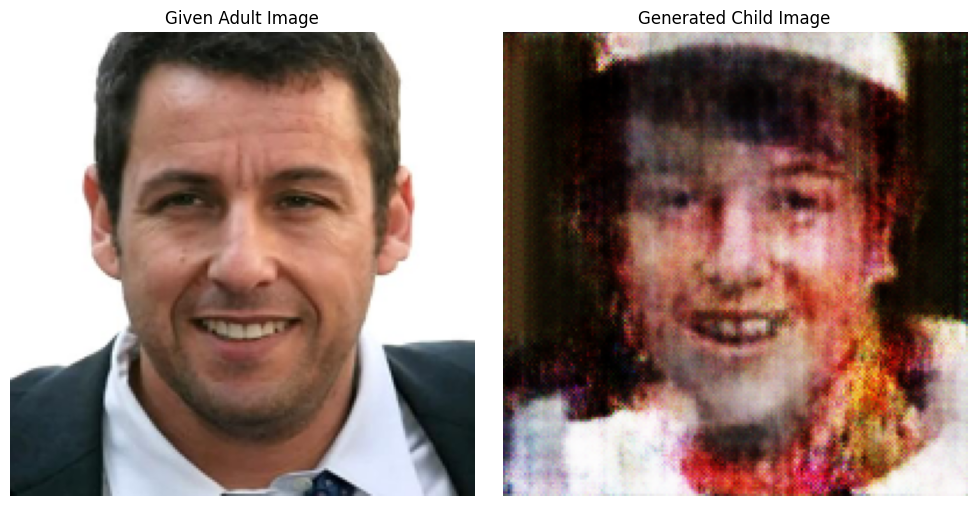

In [22]:
# Visualization: Given Adult Image and Generated Child Image
def visualize_adult_and_generated_child(generator, test_adult_image, device):
    generator.eval()  # Set the model to evaluation mode

    # Ensure the test adult image is in the correct shape and type
    if test_adult_image.dtype != np.uint8:
        test_adult_image = (test_adult_image * 255).astype(np.uint8)

    # Convert the adult image to a tensor
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    input_tensor = transform(Image.fromarray(test_adult_image)).unsqueeze(0).to(device)

    # Generate the child version
    with torch.no_grad():
        generated_child = generator(input_tensor)

    # Post-process the generated child image: Denormalize and convert back to numpy array
    generated_child = generated_child.squeeze(0).cpu().numpy()  # Remove batch dimension
    generated_child = (generated_child * 0.5 + 0.5).clip(0, 1)  # Denormalize to [0, 1]
    generated_child = (generated_child.transpose(1, 2, 0) * 255).astype(np.uint8)  # CxHxW to HxWxC

    # Plot the images side by side
    plt.figure(figsize=(10, 5))

    # Plot the given adult image
    plt.subplot(1, 2, 1)
    plt.imshow(test_adult_image)
    plt.title("Given Adult Image")
    plt.axis("off")

    # Plot the generated child image
    plt.subplot(1, 2, 2)
    plt.imshow(generated_child)
    plt.title("Generated Child Image")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# Example usage
test_adult_image = adult_images[18]  # Replace with an unseen adult image
visualize_adult_and_generated_child(generator, test_adult_image, device)
